# Model Object

In [2]:
# imports
import math
import numpy as np 
import matplotlib.pyplot as plt 

from nnfs.datasets import sine_data

np.random.seed(67)

# Initialize Current Code

In [19]:
class Loss:

    # remember trainable layers
    def remember_trainable_layers(self, trainable_layers):
        self.trainable_layers = trainable_layers

    def regularization_loss(self):
        regularization_loss = 0

        for layer in self.trainable_layers:
            if layer.weight_regularizer_l1 > 0:
                regularization_loss += layer.weight_regularizer_l1 * np.sum(abs(layer.weights))
            if layer.bias_regularizer_l1 > 0:
                regularization_loss += layer.bias_regularizer_l1 * np.sum(abs(layer.biases))
            if layer.weight_regularizer_l2 > 0:
                regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
            if layer.bias_regularizer_l2 > 0:
                regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss, self.regularization_loss()
    
class Loss_MeanSquareError(Loss):
    def forward(self, y_pred, y_true):

        sample_losses = np.mean((y_true - y_pred) ** 2, axis=-1)
        return sample_losses
    
    def backward(self, dvalues, y_true):
        samples = len(y_true)

        outputs = len(dvalues[0])

        self.dinputs = -2 * (y_true - dvalues) / outputs
        
        self.dinputs = self.dinputs / samples

class Loss_BinaryCrossEntropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Clip data to prevent divsion by 0
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        sample_losses = - (y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
        
        loss_mean = np.mean(sample_losses, axis=-1)
        return loss_mean

    # Backward pass 
    def backward(self, dvalues, y_true): 
        # Number of samples 
        samples = len(dvalues) 
        # Number of outputs in every sample 
        # We'll use the first sample to count them 
        outputs = len(dvalues[0]) 
 
        # Clip data to prevent division by 0 
        clipped_dvalues = np.clip(dvalues, 1e-7, 1 - 1e-7) 
 
        # Calculate gradient 
        self.dinputs = -(y_true / clipped_dvalues - (1 - y_true) / (1 - clipped_dvalues)) / outputs 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples     

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        # initialize here
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        # backwards pass
        # integrate l1 regularizer here
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        # integrate l2 regularizer here
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 
    
    def predictions(self, outputs):
        return outputs # TODO

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
    
    # add prediction
    def predictions(self, outputs):
        return np.argmax(outputs, axis=-1)

class Activation_Sigmoid:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))
    
    def backward(self, dvalues):
        self.dinputs = dvalues * (1 - self.output) * self.output

    # add prediction
    def predictions(self, outputs):
        return (outputs > 0.5) * 1

class Activation_Linear:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = inputs
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
    
    # add prediction
    def predictions(self, outputs):
        return outputs

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

### Accuracy Object

class Accuracy:
    def calculate(self, predictions, y):
        comparisons = self.compare(predictions, y)
        accuracy = np.mean(comparisons)
        return accuracy

class Accuracy_Regression(Accuracy):
    def __init__(self):
        self.precision = None

    def init(self, y, reinit=False):
        if self.precision is None or reinit == True:
            self.precision = np.std(y) / 250

    def compare(self, y_pred, y_true):
        return np.absolute(y_pred - y) < self.precision

class Layer_Input:
    def forward(self, inputs):
        self.output = inputs

### Model Object

class Model:
    def __init__(self):
        self.layers = []
    
    def add(self, layer):
        self.layers.append(layer)
    
    def set(self, *, loss, optimizer, accuracy):
        self.loss = loss
        self.optimizer = optimizer
        self.accuracy = accuracy
    
    def train(self, X, y, *, epochs=1, print_every=1):
        self.accuracy.init(y)

        for epoch in range(1, epochs+1):
            
            output = self.forward(X)

            data_loss, regularization_loss = self.loss.calculate(output, y)
            loss = data_loss + regularization_loss

            predictions = self.output_layer_activation.predictions(output)
            accuracy = self.accuracy.calculate(predictions, y)

            self.backward(output, y)

            self.optimizer.pre_update_params()
            for trainable_layer in self.trainable_layers:
                self.optimizer.update_params(trainable_layer)
            self.optimizer.post_update_params()

            if not epoch % print_every: 
                print(f'epoch: {epoch}, ' + 
                      f'acc: {accuracy:.3f}, ' + 
                      f'loss: {loss:.3f} (' + 
                      f'data_loss: {data_loss:.3f}, ' + 
                      f'reg_loss: {regularization_loss:.3f}), ' + 
                      f'lr: {self.optimizer.current_learning_rate}')             

    def finalize(self):
        self.input_layer = Layer_Input()

        layer_count = len(self.layers)

        self.trainable_layers = []

        for i in range(layer_count):

            if i == 0:
                self.layers[i].prev = self.input_layer
                self.layers[i].next = self.layers[i+1]
            
            # every layer except last layer
            elif i < layer_count - 1:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.layers[i+1]
            
            # last layer should be the loss
            else:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.loss
                self.output_layer_activation = self.layers[i]

            # if layers has attribute weights, append to trainable layers
            if hasattr(self.layers[i], "weights"):
                self.trainable_layers.append(self.layers[i])
            
        self.loss.remember_trainable_layers(self.trainable_layers)
    
    def forward(self, X):
        # initialize input layer
        self.input_layer.forward(X)

        for layer in self.layers:
            layer.forward(layer.prev.output)
        
        return layer.output

    def backward(self, output, y):
        
        # set dinputs by passing in forward
        # outputs to backwards pass in loss fn
        self.loss.backward(output, y)

        for layer in reversed(self.layers):
            layer.backward(layer.next.dinputs)




# Evaluate Sine Data

In [17]:
X, y = sine_data()

model = Model()
model.add(Layer_Dense(1, 64))
model.add(Activation_ReLU())
model.add(Layer_Dense(64, 64))
model.add(Activation_ReLU())
model.add(Layer_Dense(64, 1))
model.add(Activation_Linear())

print(model.layers)

model.set(loss=Loss_MeanSquareError(), optimizer=Optimizer_Adam(learning_rate=0.005, decay=1e-3), accuracy=Accuracy_Regression())

model.finalize()

model.train(X, y, epochs=10_000, print_every=1000)

[<__main__.Layer_Dense object at 0x0000019A9026FCB0>, <__main__.Activation_ReLU object at 0x0000019A9026F8C0>, <__main__.Layer_Dense object at 0x0000019A912E47D0>, <__main__.Activation_ReLU object at 0x0000019A912E4690>, <__main__.Layer_Dense object at 0x0000019A912E4550>, <__main__.Activation_Linear object at 0x0000019A9026F770>]
epoch: 1000, acc: 0.442, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.002501250625312656
epoch: 2000, acc: 0.476, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0016672224074691564


KeyboardInterrupt: 

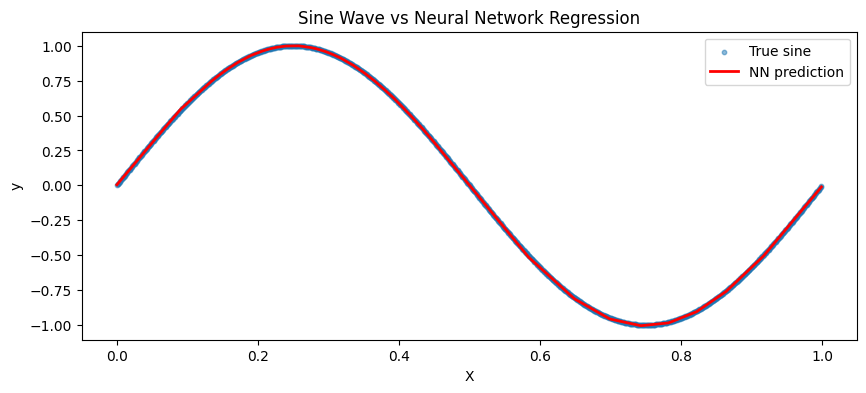

In [13]:
### plot
X_plot = X.flatten()
sort_idx = np.argsort(X_plot)

predictions = model.forward(X)

plt.figure(figsize=(10, 4))
plt.scatter(X_plot, y.flatten(), s=10, alpha=0.5, label='True sine')
plt.plot(X_plot[sort_idx], predictions.flatten()[sort_idx], color='red', linewidth=2, label='NN prediction')
plt.legend()
plt.title('Sine Wave vs Neural Network Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()


# Adding Categorical Accuracy

In [53]:
class Loss:
    def remember_trainable_layers(self, trainable_layers):
        self.trainable_layers = trainable_layers

    def regularization_loss(self):
        regularization_loss = 0

        for layer in self.trainable_layers:
            if layer.weight_regularizer_l1 > 0:
                regularization_loss += layer.weight_regularizer_l1 * np.sum(abs(layer.weights))
            if layer.bias_regularizer_l1 > 0:
                regularization_loss += layer.bias_regularizer_l1 * np.sum(abs(layer.biases))
            if layer.weight_regularizer_l2 > 0:
                regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
            if layer.bias_regularizer_l2 > 0:
                regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

    def calculate(self, output, y, include_regularization=False):
        
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        if not include_regularization:
            return data_loss
        return data_loss, self.regularization_loss()

class Loss_MeanSquareError(Loss):
    def forward(self, y_pred, y_true):

        sample_losses = np.mean((y_true - y_pred) ** 2, axis=-1)
        return sample_losses
    
    def backward(self, dvalues, y_true):
        samples = len(y_true)

        outputs = len(dvalues[0])

        self.dinputs = -2 * (y_true - dvalues) / outputs
        
        self.dinputs = self.dinputs / samples

class Loss_BinaryCrossEntropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Clip data to prevent divsion by 0
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        sample_losses = - (y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
        
        loss_mean = np.mean(sample_losses, axis=-1)
        return loss_mean

    # Backward pass 
    def backward(self, dvalues, y_true): 
        # Number of samples 
        samples = len(dvalues) 
        # Number of outputs in every sample 
        # We'll use the first sample to count them 
        outputs = len(dvalues[0]) 
 
        # Clip data to prevent division by 0 
        clipped_dvalues = np.clip(dvalues, 1e-7, 1 - 1e-7) 
 
        # Calculate gradient 
        self.dinputs = -(y_true / clipped_dvalues - (1 - y_true) / (1 - clipped_dvalues)) / outputs 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples    

class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples  

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        # initialize here
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs, training):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        # backwards pass
        # integrate l1 regularizer here
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        # integrate l2 regularizer here
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs, training): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 
    
    def predictions(self, outputs):
        return outputs # TODO

class Activation_Softmax: 
    def forward(self, inputs, training): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
    
    # add prediction
    def predictions(self, outputs):
        return np.argmax(outputs, axis=-1)

class Activation_Sigmoid:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))
    
    def backward(self, dvalues):
        self.dinputs = dvalues * (1 - self.output) * self.output

    # add prediction
    def predictions(self, outputs):
        return (outputs > 0.5) * 1

class Activation_Linear:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = inputs
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
    
    # add prediction
    def predictions(self, outputs):
        return outputs

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

### Accuracy Object

class Accuracy:
    def calculate(self, predictions, y):
        comparisons = self.compare(predictions, y)
        accuracy = np.mean(comparisons)
        return accuracy

class Accuracy_Regression(Accuracy):
    def __init__(self):
        self.precision = None

    def init(self, y, reinit=False):
        if self.precision is None or reinit == True:
            self.precision = np.std(y) / 250

    def compare(self, y_pred, y_true):
        return np.absolute(y_pred - y) < self.precision

## Accuracy Categorical

class Accuracy_Categorical(Accuracy):
    def init(self, y, reinit=False):
        pass
    def compare(self, y_pred, y):
        if y.shape == 2:
            y = np.argmax(y, axis=1)
        return y_pred == y

class Layer_Input:
    def forward(self, inputs):
        self.output = inputs

class Model:
    def __init__(self):
        self.layers = []
    
    def add(self, layer):
        self.layers.append(layer)
    
    def set(self, *, loss, optimizer, accuracy):
        self.loss = loss
        self.optimizer = optimizer
        self.accuracy = accuracy
    
    def train(self, X, y, *, epochs=1, print_every=1, validation_data=None):
        self.accuracy.init(y)

        for epoch in range(1, epochs+1):
            
            output = self.forward(X)

            data_loss, regularization_loss = self.loss.calculate(output, y, include_regularization=True)
            loss = data_loss + regularization_loss

            predictions = self.output_layer_activation.predictions(output)
            accuracy = self.accuracy.calculate(predictions, y)

            self.backward(output, y)

            self.optimizer.pre_update_params()
            for trainable_layer in self.trainable_layers:
                self.optimizer.update_params(trainable_layer)
            self.optimizer.post_update_params()

            if not epoch % print_every: 
                print(f'epoch: {epoch}, ' + 
                      f'acc: {accuracy:.3f}, ' + 
                      f'loss: {loss:.3f} (' + 
                      f'data_loss: {data_loss:.3f}, ' + 
                      f'reg_loss: {regularization_loss:.3f}), ' + 
                      f'lr: {self.optimizer.current_learning_rate}')   

        if validation_data is not None: 

            # For better readability 
            X_val, y_val = validation_data 

            # Perform the forward pass 
            output = self.forward(X_val) 

            # Calculate the loss 
            loss = self.loss.calculate(output, y_val) 

            # Get predictions and calculate an accuracy 
            predictions = self.output_layer_activation.predictions( 
                            output) 
            accuracy = self.accuracy.calculate(predictions, y_val) 

            # Print a summary 
            print(f'validation, ' + 
                    f'acc: {accuracy:.3f}, ' + 
                    f'loss: {loss:.3f}')           

    def finalize(self):
        self.input_layer = Layer_Input()

        layer_count = len(self.layers)

        self.trainable_layers = []

        for i in range(layer_count):

            if i == 0:
                self.layers[i].prev = self.input_layer
                self.layers[i].next = self.layers[i+1]
            
            # every layer except last layer
            elif i < layer_count - 1:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.layers[i+1]
            
            # last layer should be the loss
            else:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.loss
                self.output_layer_activation = self.layers[i]

            # if layers has attribute weights, append to trainable layers
            if hasattr(self.layers[i], "weights"):
                self.trainable_layers.append(self.layers[i])
            
        self.loss.remember_trainable_layers(self.trainable_layers)
    
    def forward(self, X):
        # initialize input layer
        self.input_layer.forward(X)

        for layer in self.layers:
            layer.forward(layer.prev.output)
        
        return layer.output

    def backward(self, output, y):
        
        # set dinputs by passing in forward
        # outputs to backwards pass in loss fn
        self.loss.backward(output, y)

        for layer in reversed(self.layers):
            layer.backward(layer.next.dinputs)

# Test with Spiral Data

In [27]:
from nnfs.datasets import spiral_data

# Create train and test dataset 
X, y = spiral_data(samples=100, classes=2) 
X_test, y_test = spiral_data(samples=100, classes=2) 
 
# Reshape labels to be a list of lists 
# Inner list contains one output (either 0 or 1) 
# per each output neuron, 1 in this case 
y = y.reshape(-1, 1) 
y_test = y_test.reshape(-1, 1) 
 
# Instantiate the model 
model = Model() 
 
# Add layers 
model.add(Layer_Dense(2, 64, weight_regularizer_l2=5e-4, 
                             bias_regularizer_l2=5e-4)) 
model.add(Activation_ReLU()) 
model.add(Layer_Dense(64, 1)) 
model.add(Activation_Sigmoid()) 
 
  
# Set loss, optimizer and accuracy objects 
model.set(loss=Loss_BinaryCrossEntropy(), optimizer=Optimizer_Adam(decay=5e-7),accuracy=Accuracy_Categorical()) 
# Finalize the model 
model.finalize() 
# Train the model 
model.train(X, y,  validation_data=(X_test, y_test), 

epochs=10000,  print_every=1000)

epoch: 1000, acc: 0.650, loss: 0.622 (data_loss: 0.616, reg_loss: 0.007), lr: 0.000999500749375687
epoch: 2000, acc: 0.720, loss: 0.562 (data_loss: 0.540, reg_loss: 0.022), lr: 0.0009990014980027463
epoch: 3000, acc: 0.755, loss: 0.518 (data_loss: 0.485, reg_loss: 0.033), lr: 0.000998502745133672
epoch: 4000, acc: 0.870, loss: 0.443 (data_loss: 0.392, reg_loss: 0.051), lr: 0.0009980044900222008
epoch: 5000, acc: 0.920, loss: 0.374 (data_loss: 0.308, reg_loss: 0.066), lr: 0.000997506731923557
epoch: 6000, acc: 0.920, loss: 0.338 (data_loss: 0.266, reg_loss: 0.072), lr: 0.0009970094700944517
epoch: 7000, acc: 0.940, loss: 0.303 (data_loss: 0.227, reg_loss: 0.076), lr: 0.000996512703793076
epoch: 8000, acc: 0.945, loss: 0.274 (data_loss: 0.200, reg_loss: 0.075), lr: 0.0009960164322790998
epoch: 9000, acc: 0.950, loss: 0.250 (data_loss: 0.179, reg_loss: 0.071), lr: 0.000995520654813666
epoch: 10000, acc: 0.950, loss: 0.235 (data_loss: 0.167, reg_loss: 0.068), lr: 0.0009950253706593885
vali

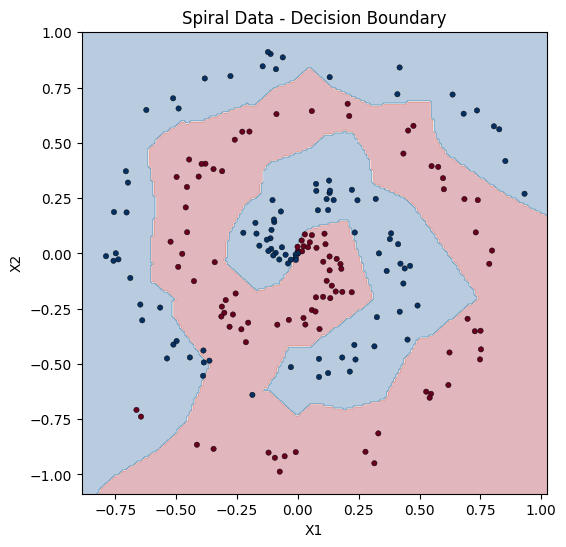

In [29]:
# Create a mesh grid over the data space
h = 0.01
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Run forward pass on every point in the grid
grid = np.c_[xx.ravel(), yy.ravel()]
predictions = model.forward(grid)
predictions = (predictions > 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap='RdBu')
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='RdBu', s=15, edgecolors='k', linewidths=0.3)
plt.title('Spiral Data - Decision Boundary')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


# Modifying `Layer_Dropout`

When we’re not training, we can set the output to the input directly in the ​Layer_Dropout​ class and return from the method without changing outputs:

In [54]:
# Model Class
class Model:
    def __init__(self):
        self.layers = []
        self.softmax_classifier_output = None
    
    def add(self, layer):
        self.layers.append(layer)
    
    def set(self, *, loss, optimizer, accuracy):
        self.loss = loss
        self.optimizer = optimizer
        self.accuracy = accuracy
    
    def train(self, X, y, *, epochs=1, print_every=1, validation_data=None):
        self.accuracy.init(y)

        for epoch in range(1, epochs+1):
            
            output = self.forward(X, training=True)

            data_loss, regularization_loss = self.loss.calculate(output, y, include_regularization=True)
            loss = data_loss + regularization_loss

            predictions = self.output_layer_activation.predictions(output)
            accuracy = self.accuracy.calculate(predictions, y)

            self.backward(output, y)

            self.optimizer.pre_update_params()
            for trainable_layer in self.trainable_layers:
                self.optimizer.update_params(trainable_layer)
            self.optimizer.post_update_params()

            if not epoch % print_every: 
                print(f'epoch: {epoch}, ' + 
                      f'acc: {accuracy:.3f}, ' + 
                      f'loss: {loss:.3f} (' + 
                      f'data_loss: {data_loss:.3f}, ' + 
                      f'reg_loss: {regularization_loss:.3f}), ' + 
                      f'lr: {self.optimizer.current_learning_rate}')   

        if validation_data is not None: 

            # For better readability 
            X_val, y_val = validation_data 

            # Perform the forward pass 
            output = self.forward(X_val, training=False) 

            # Calculate the loss 
            loss = self.loss.calculate(output, y_val) 

            # Get predictions and calculate an accuracy 
            predictions = self.output_layer_activation.predictions( 
                            output) 
            accuracy = self.accuracy.calculate(predictions, y_val) 

            # Print a summary 
            print(f'validation, ' + 
                    f'acc: {accuracy:.3f}, ' + 
                    f'loss: {loss:.3f}')           

    def finalize(self):
        self.input_layer = Layer_Input()

        layer_count = len(self.layers)

        self.trainable_layers = []

        for i in range(layer_count):

            if i == 0:
                self.layers[i].prev = self.input_layer
                self.layers[i].next = self.layers[i+1]
            
            # every layer except last layer
            elif i < layer_count - 1:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.layers[i+1]
            
            # last layer should be the loss
            else:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.loss
                self.output_layer_activation = self.layers[i]

            # if layers has attribute weights, append to trainable layers
            if hasattr(self.layers[i], "weights"):
                self.trainable_layers.append(self.layers[i])
            
        self.loss.remember_trainable_layers(self.trainable_layers)

        # If output activation is Softmax and 
        # loss function is Categorical Cross-Entropy 
        # create an object of combined activation 
        # and loss function containing 
        # faster gradient calculation 
        if isinstance(self.layers[-1], Activation_Softmax) and isinstance(self.loss, Loss_CategoricalCrossentropy): 
            # Create an object of combined activation 
            # and loss functions 
            self.softmax_classifier_output = Activation_Softmax_Loss_CategoricalCrossentropy() 
    
    def forward(self, X, training):
        # initialize input layer
        self.input_layer.forward(X, training)

        for layer in self.layers:
            layer.forward(layer.prev.output, training)
        
        return layer.output

    def backward(self, output, y):
        
        # If softmax classifier 
        if self.softmax_classifier_output is not None: 
            # First call backward method 
            # on the combined activation/loss 
            # this will set dinputs property 
            self.softmax_classifier_output.backward(output, y) 
 
            # Since we'll not call backward method of the last layer 
            # which is Softmax activation 
            # as we used combined activation/loss 
            # object, let's set dinputs in this object 
            self.layers[-1].dinputs = self.softmax_classifier_output.dinputs 
 
            # Call backward method going through 
            # all the objects but last 
            # in reversed order passing dinputs as a parameter 
            for layer in reversed(self.layers[:-1]): 
                layer.backward(layer.next.dinputs) 
 
            return         
        # set dinputs by passing in forward
        # outputs to backwards pass in loss fn
        self.loss.backward(output, y)

        for layer in reversed(self.layers):
            layer.backward(layer.next.dinputs)
        

In [55]:
class Layer_Dropout:
    def __init__(self, rate):
        self.rate = rate
    
    def forward(self, inputs, training):
        self.inputs = inputs

        if not training:
            self.output = self.inputs.copy()
            return self.output
        
        self.binary_mask = np.random.binomial(1, 1-self.rate, self.inputs.shape)
        self.output = self.inputs * self.binary_mask

    def backward(self, dvalues):
        self.dinputs = dvalues * self.binary_mask

In [56]:
class Layer_Input:
    def forward(self, inputs, training):
        self.output = inputs

In [57]:
# Softmax classifier - combined Softmax activation 
# and cross-entropy loss for faster backward step 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
 
    # Backward pass 
    def backward(self, dvalues, y_true): 
 
        # Number of samples 
        samples = len(dvalues) 
 
        # Copy so we can safely modify 
        self.dinputs = dvalues.copy() 
        # Calculate gradient 
        self.dinputs[range(samples), y_true] -= 1 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples 

# Testing

In [59]:
# Create dataset 
X, y = spiral_data(samples=1000, classes=3) 
X_test, y_test = spiral_data(samples=100, classes=3) 
 
# Instantiate the model 
model = Model() 

# Add layers 
model.add(Layer_Dense(2, 64, weight_regularizer_l2=5e-4, 
                              bias_regularizer_l2=5e-4)) 
model.add(Activation_ReLU()) 
model.add(Layer_Dropout(0.1)) 
model.add(Layer_Dense(64, 3)) 
model.add(Activation_Softmax()) 
 
# Set loss, optimizer and accuracy objects 
model.set( 
    loss=Loss_CategoricalCrossentropy(), 
    optimizer=Optimizer_Adam(learning_rate=0.05, decay=5e-5), 
    accuracy=Accuracy_Categorical() 
) 
 
# Finalize the model 
model.finalize() 
 
# Train the model 
model.train(X, y, validation_data=(X_test, y_test), 
            epochs=10000, print_every=1000)

epoch: 1000, acc: 0.713, loss: 0.702 (data_loss: 0.664, reg_loss: 0.038), lr: 0.04762131530072861
epoch: 2000, acc: 0.723, loss: 0.682 (data_loss: 0.648, reg_loss: 0.034), lr: 0.045456611664166556
epoch: 3000, acc: 0.719, loss: 0.660 (data_loss: 0.629, reg_loss: 0.032), lr: 0.043480151310926564
epoch: 4000, acc: 0.714, loss: 0.634 (data_loss: 0.603, reg_loss: 0.031), lr: 0.04166840285011875
epoch: 5000, acc: 0.730, loss: 0.644 (data_loss: 0.615, reg_loss: 0.030), lr: 0.04000160006400256
epoch: 6000, acc: 0.727, loss: 0.655 (data_loss: 0.626, reg_loss: 0.029), lr: 0.03846301780837725
epoch: 7000, acc: 0.715, loss: 0.636 (data_loss: 0.607, reg_loss: 0.029), lr: 0.03703840882995667
epoch: 8000, acc: 0.723, loss: 0.630 (data_loss: 0.602, reg_loss: 0.028), lr: 0.03571556127004536
epoch: 9000, acc: 0.732, loss: 0.613 (data_loss: 0.585, reg_loss: 0.028), lr: 0.034483947722335255
epoch: 10000, acc: 0.730, loss: 0.633 (data_loss: 0.606, reg_loss: 0.027), lr: 0.03333444448148271
validation, acc:

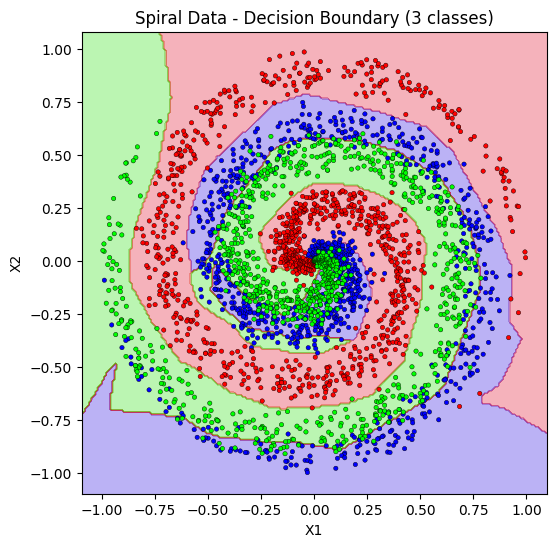

In [ ]:
# Spiral Data - Decision Boundary (3 classes)
h = 0.01
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid = np.c_[xx.ravel(), yy.ravel()]
predictions = model.forward(grid, training=False)
predictions = np.argmax(predictions, axis=1).reshape(xx.shape)  # <-- argmax for 3 classes

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap='brg')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', s=10, edgecolors='k', linewidths=0.3)
plt.title('Spiral Data - Decision Boundary (3 classes)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()
